# Task 2: Stock Price Prediction
A deep learning model trained on 4 years of Apple Inc. (AAPL) historical stock data fetched directly from Yahoo Finance to predict future closing prices. Historical prices are preprocessed with feature engineering (moving averages, lag features) and normalized using MinMaxScaler, then fed into a two-layer LSTM neural network which learns temporal patterns in the price sequence to forecast the next day's closing price.

In [1]:
# Fetching latest data from Yahoo Finance
!pip install yfinance

In [37]:
# Importing necessary libraries
import yfinance as yf
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Getting 4 years of data till April and displaying first 5 rows
df = yf.download('AAPL', start = '2022-04-01', end = '2026-04-01')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-04-01,170.786255,171.344739,168.464170,170.511916,78751300
2022-04-04,174.832764,174.881756,170.913625,171.041002,76468400
2022-04-05,171.521088,174.695595,170.894026,173.911764,73401800
2022-04-06,168.356369,170.119984,166.690738,168.875654,89058800
2022-04-07,168.660095,169.855433,166.416395,167.699911,77594700


In [18]:
# Verifying last 5 rows
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-03-25,252.619995,255.000000,251.600006,254.100006,28476700
2026-03-26,252.889999,257.000000,250.770004,252.119995,41796700
2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200
2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100


In [19]:
# Checking data types and no. of null values of each column
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1002 entries, 2022-04-01 to 2026-03-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1002 non-null   float64
 1   (High, AAPL)    1002 non-null   float64
 2   (Low, AAPL)     1002 non-null   float64
 3   (Open, AAPL)    1002 non-null   float64
 4   (Volume, AAPL)  1002 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.0 KB


Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [20]:
# Providing cleaner column names for readability
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2022-04-01,170.786255,171.344739,168.464170,170.511916,78751300
2022-04-04,174.832764,174.881756,170.913625,171.041002,76468400
2022-04-05,171.521088,174.695595,170.894026,173.911764,73401800
2022-04-06,168.356369,170.119984,166.690738,168.875654,89058800
2022-04-07,168.660095,169.855433,166.416395,167.699911,77594700


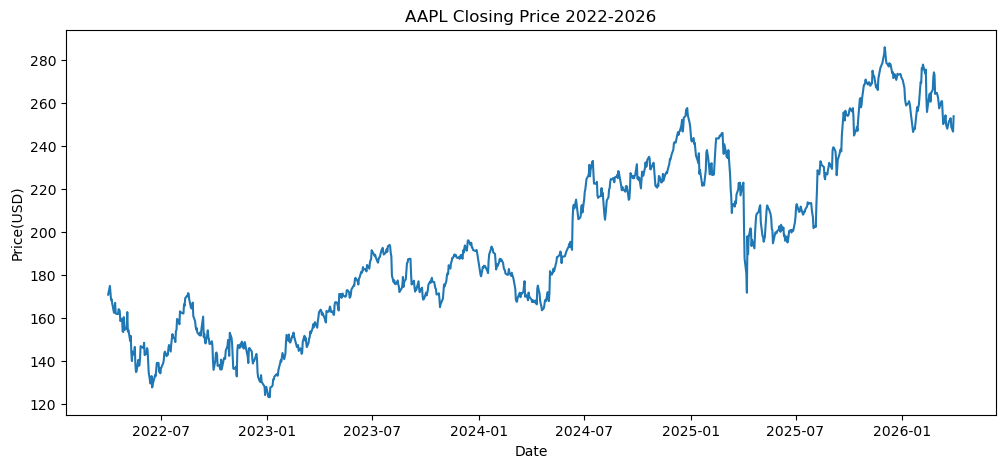

In [21]:
# Visualizing a line chart of the data for trends and dips
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'])
plt.title('AAPL Closing Price 2022-2026')
plt.xlabel('Date')
plt.ylabel('Price(USD)')
plt.show()

In [22]:
# Creating a lag feature of closing prices
df['Previous_Close'] = df['Close'].shift(1)
df.head()

,Close,High,Low,Open,Volume,Previous_Close
Date,,,,,,
2022-04-01,170.786255,171.344739,168.464170,170.511916,78751300,NaN
2022-04-04,174.832764,174.881756,170.913625,171.041002,76468400,170.786255
2022-04-05,171.521088,174.695595,170.894026,173.911764,73401800,174.832764
2022-04-06,168.356369,170.119984,166.690738,168.875654,89058800,171.521088
2022-04-07,168.660095,169.855433,166.416395,167.699911,77594700,168.356369


In [23]:
# Dropping the null value rows (first row)
df=df.dropna()

In [26]:
# Finding price diff, avg closing price of 7 and 21 days and dropping null value rows 
df['Price_Change'] = df['Close'] - df['Previous_Close']

df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA21'] = df['Close'].rolling(window=21).mean()

df.dropna(inplace=True)
df.head()

,Close,High,Low,Open,Volume,Previous_Close,Price_Change,MA7,MA21
Date,,,,,,,,,
2022-05-03,156.256012,157.461158,153.159905,154.952897,88966500,154.766769,1.489243,156.062881,162.343297
2022-05-04,162.663834,163.114526,156.040481,156.442196,108256500,156.256012,6.407822,156.502380,161.763824
2022-05-05,153.600861,160.763085,151.817645,160.537738,130525300,162.663834,-9.062973,156.498186,160.910480
2022-05-06,154.326935,156.446383,151.285134,153.080776,116124600,153.600861,0.726074,156.629909,160.242411
2022-05-09,149.204895,152.904113,148.645605,152.021003,131577900,154.326935,-5.122040,155.040331,159.315973


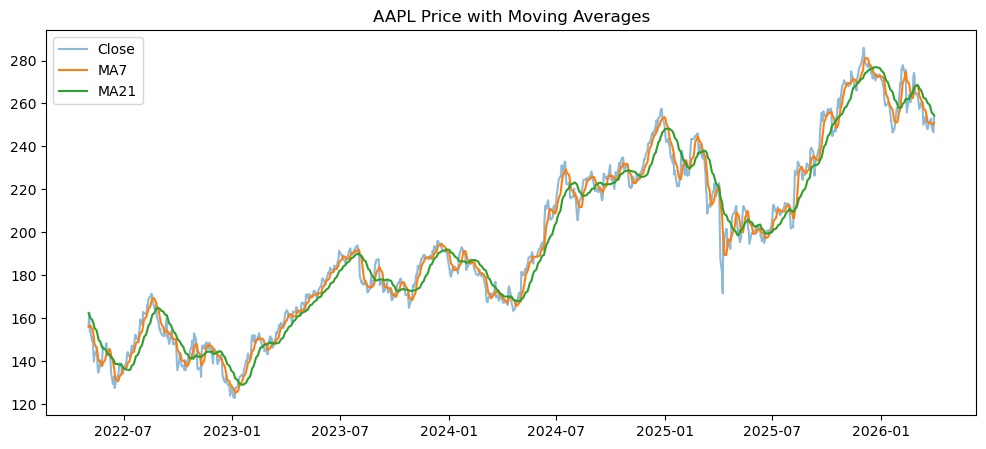

In [29]:
# Comparing graphs of closing, MA7 and MA21
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'], label = 'Close', alpha=0.5)
plt.plot(df.index, df['MA7'], label = 'MA7')
plt.plot(df.index, df['MA21'], label = 'MA21')
plt.title('AAPL Price with Moving Averages')
plt.legend()
plt.show()

In [30]:
# Installing tensorflow (keras) to use LSTM model
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.8/351.2 MB 4.6 MB/s eta 0:01:16
   ---------------------------------------- 2.4/351.2 MB 5.6 MB/s eta 0:01:03
   ---------------------------------------- 3.7/351.2 MB 5.8 MB/s eta 0:01:01
    --------------------------------------- 4.5/351.2 MB 5.7 MB/s eta 0:01:01
    --------------------------------------- 5.2/351.2 MB 4.9 MB/s eta 0:01:11
    --------------------------------------- 5.8/351.2 MB 4.7 MB/s eta 0:01:14
    --------------------------------------- 6.6/351.2 MB 4.3 MB/s eta 0:01:20
    --------------------------------------- 7.1/351.2 MB 4.2 MB/s eta 0:01:23
    --------------------------------------- 7.6/351.2 MB 4.0 MB/s eta 0:01:26
    --------------------------------------- 8.4/351.2 MB 4.0 MB/s eta 0:01:27
   - -------------------------------------- 9.2/351.2 MB 3.9 MB/s eta 0:01:28
   - -------------------------------------- 10.0/351.2 MB 3.9 MB/s eta 

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [33]:
# Scaling closing prices to a 0-1 range (130-230$) for better model learning
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Closed_Scaled'] = scaler.fit_transform(df[['Close']])
df[['Close', 'Closed_Scaled']].head(10)

,Close,Closed_Scaled
Date,,
2022-05-03,156.256012,0.203893
2022-05-04,162.663834,0.243235
2022-05-05,153.600861,0.187591
2022-05-06,154.326935,0.192049
2022-05-09,149.204895,0.160602
2022-05-10,151.608902,0.175361
2022-05-11,143.749329,0.127106
2022-05-12,139.883286,0.103370
2022-05-13,144.347870,0.130781


In [43]:
# Creating a 60-day sequence to predict next day price and converting to arrays and printing shapes (total,step)
sequence_length =  60

x, y = [], []

for i in range(sequence_length, len(df)):
    x.append(df['Closed_Scaled'].values[i-sequence_length:i])
    y.append(df['Closed_Scaled'].values[i])

x, y = np.array(x), np.array(y)
print(x.shape, y.shape)

(921, 60) (921,)


In [44]:
# Adding another dimension for no. of features (columns) used
x = x.reshape((x.shape[0], x.shape[1], 1))
print(x.shape)

(921, 60, 1)


In [46]:
# Splitting data into training and validation sets 
split = int(len(x) * 0.8)

x_train, x_val = x[:split], x[split:]
y_train, y_val = y[:split], y[split:]

print(f"Training samples: {len(x_train)}")
print(f"Validation samples: {len(x_val)}")

Training samples: 736
Validation samples: 185


In [55]:
# Building the LSTM model architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

model = Sequential([
    LSTM(50, return_sequences = True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences = False),
    Dropout(0.2),
    Dense(1)
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
# Training model and checking performance
model.compile(optimizer = 'adam', loss = 'mean_squared_error')

history = model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 32,
    validation_data = (x_val, y_val),
    verbose = 1)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 164ms/step - loss: 0.0408 - val_loss: 0.0456
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0070 - val_loss: 0.0096
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0041 - val_loss: 0.0050
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.0040 - val_loss: 0.0028
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0042 - val_loss: 0.0026
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0035 - val_loss: 0.0041
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - loss: 0.0031 - val_loss: 0.0028
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0032 - val_loss: 0.0023
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step


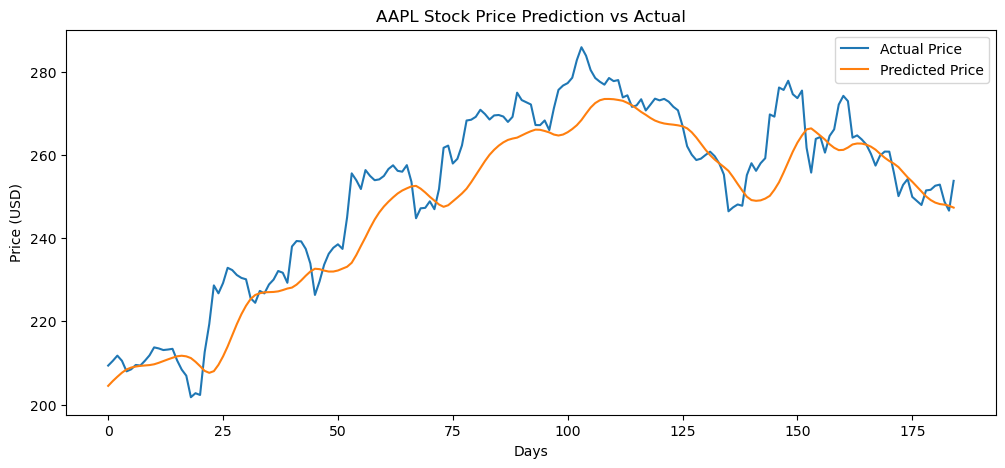

In [57]:
# Making predictions, reversing normalization and plotting predicted vs actual prices
predictions = model.predict(x_val)

predictions_unscaled = scaler.inverse_transform(predictions)
y_val_unscaled = scaler.inverse_transform(y_val.reshape(-1,1))

plt.figure(figsize=(12, 5))
plt.plot(y_val_unscaled, label='Actual Price')
plt.plot(predictions_unscaled, label='Predicted Price')
plt.title('AAPL Stock Price Prediction vs Actual')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [59]:
# Evaluating model accuracy using MAE and RMSE metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_val_unscaled, predictions_unscaled)
rmse = np.sqrt(mean_squared_error(y_val_unscaled, predictions_unscaled))

print(f"Mean Absolute Error: ${mae:.2f}")
print(f"Root Mean Squared Error: ${rmse:.2f}")

Mean Absolute Error: $6.46
Root Mean Squared Error: $8.35
